# Q1 — Visually Dominant Prompts

**Question**: If a low-bid agent's prompt is visually dominant, does it disproportionately decrease alignment of the higher-bid prompt?

**Hypothesis**:
1. Auction still gives non-trivial alignment to the dominant low-bid agent.
2. VCG payments scale with the negative externality.

**Setup**: 5 prompt pairs, linear bid sweep `b1 ∈ {0.0, 0.1, ..., 1.0}`, `b2 = 1 - b1`, k=5 samples per combo. See `claude_docs/04_2026/04_25/01_q1_dominant.md` for full details.

In [1]:
import os, json, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

ALIGN_DIR = '../alignment/q1_dominant_clip'
PROMPTS_PATH = '../prompts/q1_dominant.json'
RESULTS_DIR = '../results/q1_dominant'
os.makedirs(RESULTS_DIR, exist_ok=True)

with open(PROMPTS_PATH) as f:
    PROMPTS = json.load(f)
print(f'{len(PROMPTS)} prompts loaded')

5 prompts loaded


## 1. Load alignment data

Reads JSON files from `alignment/q1_dominant_clip/prompt_NNN/` and builds a DataFrame. **All values come from disk — no hardcoded numbers.**

In [2]:
def load_alignment(align_dir, prompt_indices=None):
    records = []
    if prompt_indices is None:
        prompt_indices = list(range(len(PROMPTS)))
    for pidx in prompt_indices:
        pdir = os.path.join(align_dir, f'prompt_{pidx:03d}')
        for jf in glob.glob(os.path.join(pdir, '*.json')):
            with open(jf) as f:
                d = json.load(f)
            meta = d['metadata']
            sc = d['alignment_scores']
            wf = d.get('welfare_metrics', {})
            records.append({
                'prompt_idx': meta['prompt_index'],
                'b1': meta['bids'][0],
                'b2': meta['bids'][1],
                'sample_idx': meta['sample_index'],
                'agent1_alignment': sc['agent1_alignment'],
                'agent2_alignment': sc['agent2_alignment'],
                'base_alignment': sc.get('base_alignment'),
                'total_welfare': wf.get('total_welfare'),
            })
    return pd.DataFrame(records)

df = load_alignment(ALIGN_DIR)
print(f'Loaded {len(df)} records')
if len(df) > 0:
    print(f'Prompts: {sorted(df.prompt_idx.unique())}')
    sample_dist = df.groupby(['prompt_idx', 'b1', 'b2']).size()
    print(f'Combos: {len(sample_dist)}, samples/combo: {sample_dist.min()}-{sample_dist.max()}')

Loaded 275 records
Prompts: [0, 1, 2, 3, 4]
Combos: 55, samples/combo: 5-5


## 2. Welfare-optimal selection per combo
For each (prompt, b1, b2), pick the welfare-optimal sample (highest `total_welfare`).

In [3]:
def welfare_optimal(df):
    if len(df) == 0:
        return df
    rows = []
    for (p, b1, b2), g in df.groupby(['prompt_idx', 'b1', 'b2']):
        best = g.loc[g['total_welfare'].idxmax()]
        rows.append({
            'prompt_idx': p, 'b1': b1, 'b2': b2,
            'agent1_alignment': best['agent1_alignment'],
            'agent2_alignment': best['agent2_alignment'],
            'base_alignment': best['base_alignment'],
            'total_welfare': best['total_welfare'],
            # Also keep mean across samples
            'agent1_alignment_mean': g['agent1_alignment'].mean(),
            'agent2_alignment_mean': g['agent2_alignment'].mean(),
            'agent1_alignment_std': g['agent1_alignment'].std(),
            'agent2_alignment_std': g['agent2_alignment'].std(),
        })
    return pd.DataFrame(rows).sort_values(['prompt_idx', 'b1'])

df_wo = welfare_optimal(df)
print(df_wo.head(15) if len(df_wo) > 0 else 'No data')

    prompt_idx   b1   b2  agent1_alignment  agent2_alignment  base_alignment  \
0            0  0.0  1.0          0.107910          0.243164        0.209961   
1            0  0.1  0.9          0.062988          0.255859        0.161133   
2            0  0.2  0.8          0.117676          0.234375        0.166992   
3            0  0.3  0.7          0.237305          0.226562        0.184570   
4            0  0.4  0.6          0.255859          0.253906        0.186523   
5            0  0.5  0.5          0.249023          0.245117        0.210938   
6            0  0.6  0.4          0.316406          0.211914        0.190430   
7            0  0.7  0.3          0.228516          0.229492        0.166016   
8            0  0.8  0.2          0.263672          0.101562        0.189453   
9            0  0.9  0.1          0.265625          0.107910        0.191406   
10           0  1.0  0.0          0.285156          0.131836        0.198242   
11           1  0.0  1.0          0.0766

## 3. Per-prompt allocation curves
Both agents' alignment vs `b1` (with `b2 = 1 - b1`).

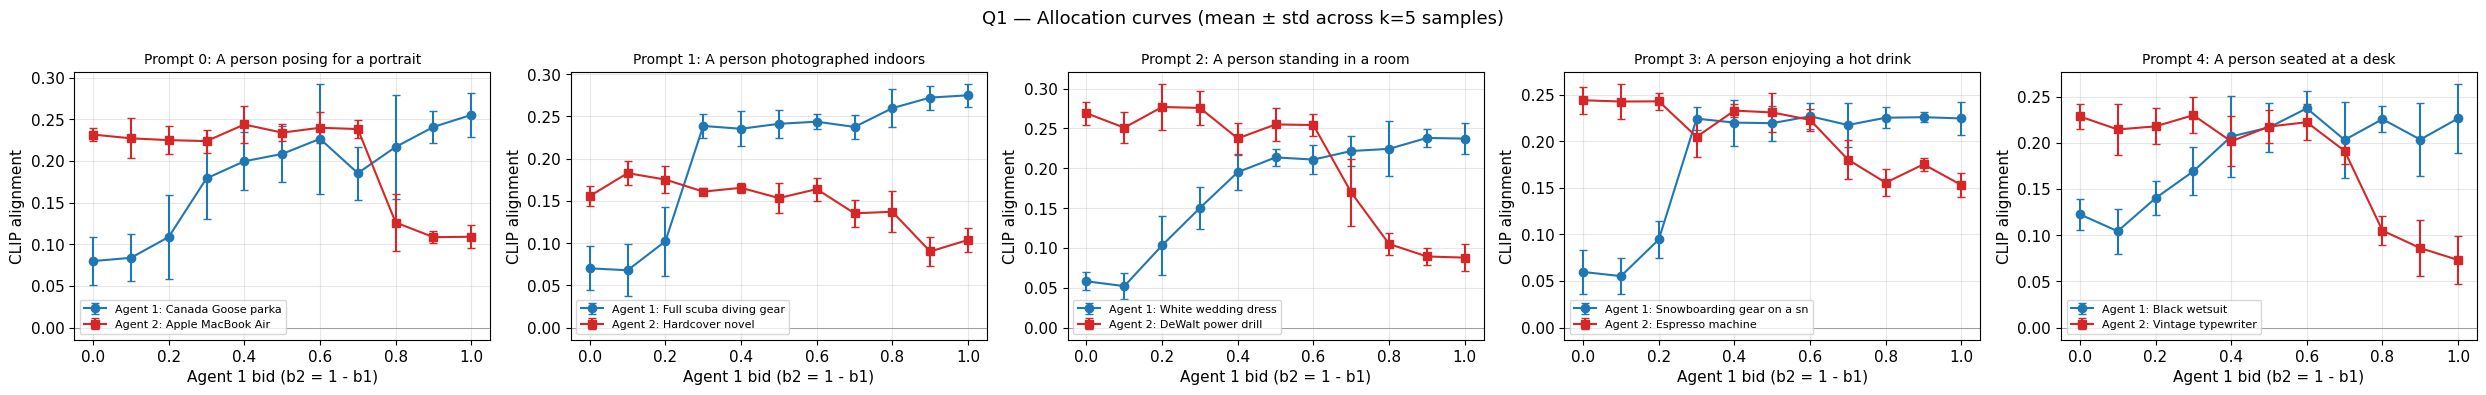

In [4]:
def plot_per_prompt_allocation(df_wo):
    if len(df_wo) == 0:
        print('No data'); return None
    pidxs = sorted(df_wo.prompt_idx.unique())
    n = len(pidxs)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4), squeeze=False)
    for col, p in enumerate(pidxs):
        sub = df_wo[df_wo.prompt_idx == p].sort_values('b1')
        ax = axes[0, col]
        ax.errorbar(sub.b1, sub.agent1_alignment_mean, yerr=sub.agent1_alignment_std,
                    fmt='o-', label=f'Agent 1: {PROMPTS[p]["agent1_prompt"][:25]}',
                    color='tab:blue', capsize=3)
        ax.errorbar(sub.b1, sub.agent2_alignment_mean, yerr=sub.agent2_alignment_std,
                    fmt='s-', label=f'Agent 2: {PROMPTS[p]["agent2_prompt"][:25]}',
                    color='tab:red', capsize=3)
        ax.axhline(0, color='gray', lw=0.5)
        ax.set_xlabel('Agent 1 bid (b2 = 1 - b1)')
        ax.set_ylabel('CLIP alignment')
        ax.set_title(f'Prompt {p}: {PROMPTS[p]["base_prompt"][:30]}', fontsize=10)
        ax.legend(fontsize=8)
    fig.suptitle('Q1 — Allocation curves (mean ± std across k=5 samples)', fontsize=13)
    plt.tight_layout()
    return fig

fig = plot_per_prompt_allocation(df_wo)
if fig:
    fig.savefig(os.path.join(RESULTS_DIR, 'allocation_per_prompt.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 4. VCG payments

For 2 agents:
- $p^{VCG}_1(b_1, b_2) = b_2 \cdot (x_2(0, b_2) - x_2(b_1, b_2))$
- $p^{VCG}_2(b_1, b_2) = b_1 \cdot (x_1(b_1, 0) - x_1(b_1, b_2))$

Counterfactuals $x_2(0, 1)$ and $x_1(1, 0)$ are in our bid grid — but with the linear sweep we only have $b_1 + b_2 = 1$, so we approximate the counterfactual for combo $(t, 1-t)$ by the alignment at $(0, 1)$ for agent 2 and $(1, 0)$ for agent 1. This represents 'what alignment does the other agent get if I'm absent'.

In [5]:
def compute_vcg(df_wo):
    rows = []
    for p in df_wo.prompt_idx.unique():
        sub = df_wo[df_wo.prompt_idx == p].sort_values('b1').reset_index(drop=True)
        # Counterfactual: agent 2 alone at b2=1.0 (so b1=0)
        x2_alone = sub.loc[sub.b1 == 0.0, 'agent2_alignment_mean'].values
        x1_alone = sub.loc[sub.b1 == 1.0, 'agent1_alignment_mean'].values
        if len(x2_alone) == 0 or len(x1_alone) == 0:
            continue
        x2_cf = float(x2_alone[0])
        x1_cf = float(x1_alone[0])
        for _, r in sub.iterrows():
            externality_to_2 = max(x2_cf - r['agent2_alignment_mean'], 0.0)
            externality_to_1 = max(x1_cf - r['agent1_alignment_mean'], 0.0)
            rows.append({
                'prompt_idx': p,
                'b1': r['b1'], 'b2': r['b2'],
                'externality_to_2': externality_to_2,  # harm A1 causes A2 (in alignment units)
                'externality_to_1': externality_to_1,  # harm A2 causes A1
                'vcg_payment_1': r['b2'] * externality_to_2,
                'vcg_payment_2': r['b1'] * externality_to_1,
            })
    return pd.DataFrame(rows)

df_vcg = compute_vcg(df_wo)
print(df_vcg.head(15) if len(df_vcg) > 0 else 'No VCG data yet')

    prompt_idx   b1   b2  externality_to_2  externality_to_1  vcg_payment_1  \
0            0  0.0  1.0          0.000000          0.175488       0.000000   
1            0  0.1  0.9          0.004492          0.171582       0.004043   
2            0  0.2  0.8          0.006641          0.146582       0.005312   
3            0  0.3  0.7          0.007812          0.076172       0.005469   
4            0  0.4  0.6          0.000000          0.055664       0.000000   
5            0  0.5  0.5          0.000000          0.046875       0.000000   
6            0  0.6  0.4          0.000000          0.028711       0.000000   
7            0  0.7  0.3          0.000000          0.069922       0.000000   
8            0  0.8  0.2          0.105566          0.038477       0.021113   
9            0  0.9  0.1          0.123145          0.014453       0.012314   
10           0  1.0  0.0          0.122656          0.000000       0.000000   
11           1  0.0  1.0          0.000000          

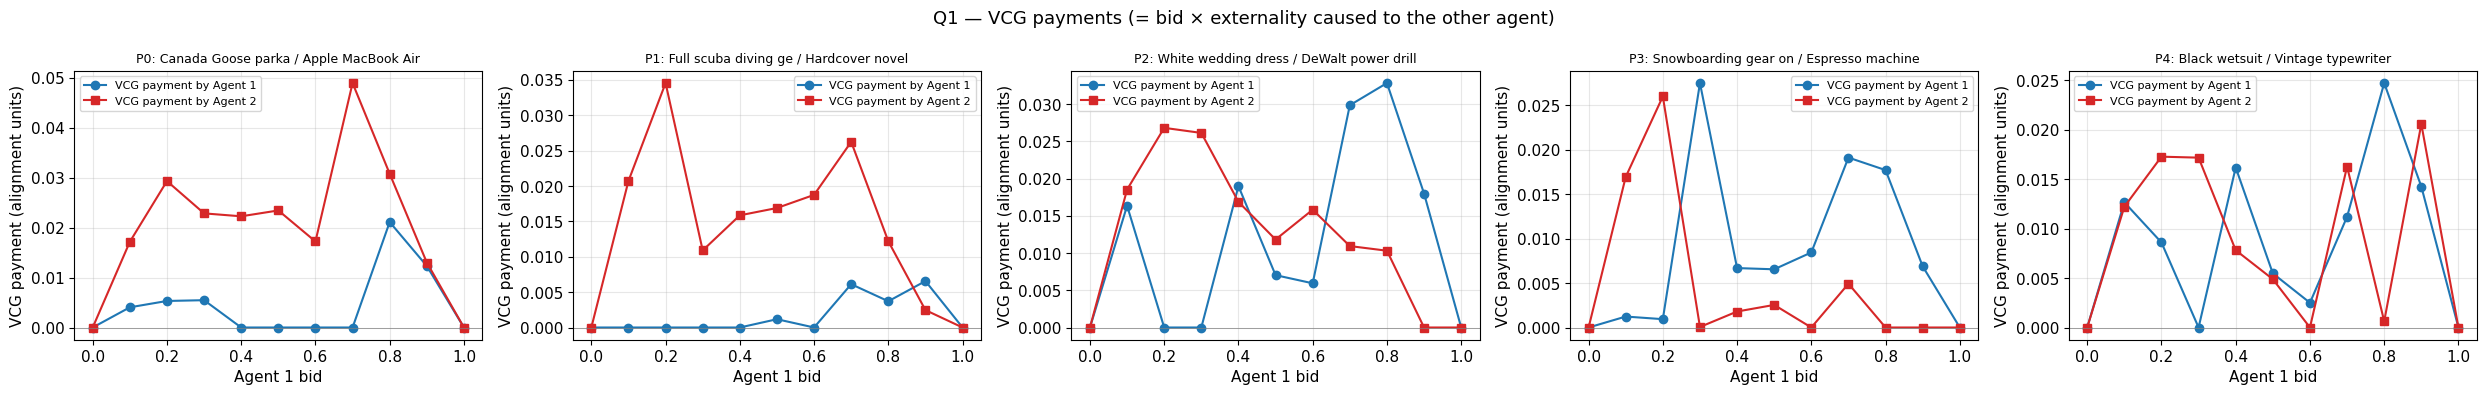

In [6]:
def plot_vcg_payments(df_vcg):
    if len(df_vcg) == 0:
        print('No VCG data'); return None
    pidxs = sorted(df_vcg.prompt_idx.unique())
    n = len(pidxs)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4), squeeze=False)
    for col, p in enumerate(pidxs):
        sub = df_vcg[df_vcg.prompt_idx == p].sort_values('b1')
        ax = axes[0, col]
        ax.plot(sub.b1, sub.vcg_payment_1, 'o-', color='tab:blue',
                label='VCG payment by Agent 1')
        ax.plot(sub.b1, sub.vcg_payment_2, 's-', color='tab:red',
                label='VCG payment by Agent 2')
        ax.axhline(0, color='gray', lw=0.5)
        ax.set_xlabel('Agent 1 bid')
        ax.set_ylabel('VCG payment (alignment units)')
        ax.set_title(f'P{p}: {PROMPTS[p]["agent1_prompt"][:20]} / {PROMPTS[p]["agent2_prompt"][:20]}', fontsize=9)
        ax.legend(fontsize=8)
    fig.suptitle('Q1 — VCG payments (= bid × externality caused to the other agent)', fontsize=13)
    plt.tight_layout()
    return fig

fig = plot_vcg_payments(df_vcg)
if fig:
    fig.savefig(os.path.join(RESULTS_DIR, 'vcg_payments.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 5. Mean across prompts (with shaded std band)

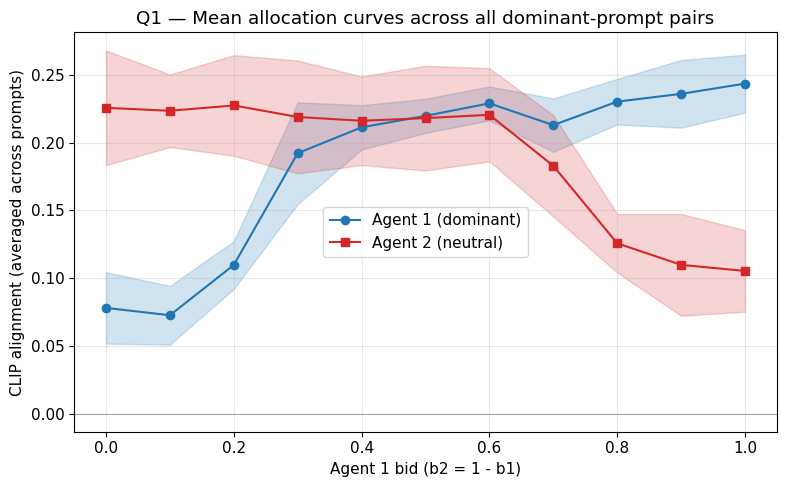

In [7]:
def plot_mean_allocation(df_wo):
    if len(df_wo) == 0:
        print('No data'); return None
    fig, ax = plt.subplots(figsize=(8, 5))
    grp = df_wo.groupby('b1').agg(
        a1_mean=('agent1_alignment_mean', 'mean'),
        a1_std=('agent1_alignment_mean', 'std'),
        a2_mean=('agent2_alignment_mean', 'mean'),
        a2_std=('agent2_alignment_mean', 'std'),
    ).reset_index()
    ax.plot(grp.b1, grp.a1_mean, 'o-', color='tab:blue', label='Agent 1 (dominant)')
    ax.fill_between(grp.b1, grp.a1_mean - grp.a1_std, grp.a1_mean + grp.a1_std, color='tab:blue', alpha=0.2)
    ax.plot(grp.b1, grp.a2_mean, 's-', color='tab:red', label='Agent 2 (neutral)')
    ax.fill_between(grp.b1, grp.a2_mean - grp.a2_std, grp.a2_mean + grp.a2_std, color='tab:red', alpha=0.2)
    ax.axhline(0, color='gray', lw=0.5)
    ax.set_xlabel('Agent 1 bid (b2 = 1 - b1)')
    ax.set_ylabel('CLIP alignment (averaged across prompts)')
    ax.set_title('Q1 — Mean allocation curves across all dominant-prompt pairs')
    ax.legend()
    plt.tight_layout()
    return fig

fig = plot_mean_allocation(df_wo)
if fig:
    fig.savefig(os.path.join(RESULTS_DIR, 'allocation_mean.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 6. Export CSV

In [8]:
if len(df_wo) > 0:
    df_wo.to_csv(os.path.join(RESULTS_DIR, 'allocation_data.csv'), index=False)
    print(f'Saved {len(df_wo)} rows to allocation_data.csv')
if len(df_vcg) > 0:
    df_vcg.to_csv(os.path.join(RESULTS_DIR, 'vcg_payments.csv'), index=False)
    print(f'Saved {len(df_vcg)} rows to vcg_payments.csv')

Saved 55 rows to allocation_data.csv
Saved 55 rows to vcg_payments.csv
